*Using Claude Code? Open it and paste this prompt:*

```
Clone https://github.com/SamDower/bluedot-tais-puzzle, cd into it, install dependencies with `pip install sentence-transformers torch`, and read the README to understand the puzzle. Then stop and wait for me — I want to drive the investigation myself, so don't run any analyses or propose which feature might be non-linear.
```

# BlueDot Technical AI Safety Puzzle #1

We trained a small classifier on short text inputs to predict eight binary features simultaneously, at over 95% accuracy on each:

- `number` — contains a digit or written-out number (3, seven, …)
- `question` — phrased as a question (ends in ?, or starts with who/what/why/…)
- `color` — contains a color word (red, blue, …)
- `food` — mentions food (pizza, apple, soup, …)
- `sentiment` — has positive vs. negative sentiment
- `country` — contains a country name (Japan, France, USA, …)
- `person` — contains a person's name (Alice, Mark, …)
- `body_part` — contains a body-part word (hand, eye, …)

After a particular layer L of this model, seven of these features are represented linearly, where a single direction in the activation space describes that feature. However, one feature is represented in a different way. Your job is to figure out which feature it is and how it is represented.

## The model architecture

The model consists of the `sentence-transformers/all-MiniLM-L6-v2` text encoder followed by a mean pool to get a single 384-dimensional representation of that input. This is then fed through a 5 layer MLP with ReLUs between the layers. The resulting 8 logits are then fed through individual sigmoid functions to recover the predicted probabilities for the 8 features.

![Model architecture](https://raw.githubusercontent.com/SamDower/bluedot-tais-puzzle/main/model_architecture.png)

The 8 probabilities don't need to sum to 1 because the eight features aren't mutually exclusive. The model was trained with per-feature binary cross-entropy across the eight outputs.

## What's in this repo

- `model.pt` — trained classifier state dict.
- `data/train.jsonl` — 7000 lines of `{"text": "...", "labels": [1, 1, 0, 0, 1, 0, 0, 1]}`. Labels indexed by `feature_names.json`.
- `data/test.jsonl` — 1500 lines, same format. Use this as a held-out test set.
- `feature_names.json` — the eight feature names, indexed 0–7.

## Setup (run this first)

Downloads the model and data. First run takes ~30s for the encoder download; re-runs are instant.

In [ ]:
!pip install -q sentence-transformers torch
![ -d /content/bluedot-tais-puzzle ] || git clone https://github.com/SamDower/bluedot-tais-puzzle.git /content/bluedot-tais-puzzle
%cd /content/bluedot-tais-puzzle

## Task 1: Find the non-linear feature.

Identify which of the eight features is not represented linearly at the specified layer activations.

### Code to get you started

In [2]:
import torch, torch.nn as nn
from sentence_transformers import SentenceTransformer

# --- 1. Define the MLP head  ---
class Head(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(384, 64), nn.ReLU(),   # hidden 0
            nn.Linear(64, 64),  nn.ReLU(),   # hidden 1
            nn.Linear(64, 64),  nn.ReLU(),   # hidden 2  ← non-linear activation here (post-ReLU)
            nn.Linear(64, 64),  nn.ReLU(),   # hidden 3
            nn.Linear(64, 8),                # logits
        )
    def forward(self, x):
        return self.layers(x)

# --- 2. Load encoder (downloaded from HF) and head (local file) ---
enc = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
m = Head()
m.load_state_dict(torch.load("model.pt", map_location="cpu", weights_only=False))
m.eval()

# --- 3. Get predictions ---
texts = [
    "Alice loves the red car she bought in Japan for two hundred dollars.",
    "Did Sarah eat pizza with her hands in Italy?",
]

with torch.no_grad():
    embeddings = torch.from_numpy(
        enc.encode(texts, convert_to_numpy=True)   # (N, 384), mean-pooled
    )
    logits = m(embeddings)                          # (N, 8)
    probs  = torch.sigmoid(logits)                  # (N, 8) — independent per feature
    preds  = (probs > 0.5).int()                    # (N, 8) — binary predictions

# --- 4. Get activations at the right spot (post-ReLU of hidden 2) ---
# layers[0:6] = Linear, ReLU, Linear, ReLU, Linear, ReLU  → output is hidden 2 post-ReLU
with torch.no_grad():
    layer2_acts = m.layers[:6](embeddings)          # (N, 64)

# --- 5. Show what we got ---
import json
feature_names = json.load(open("feature_names.json"))

print("\n\n")

for text, p in zip(texts, preds):
    active = [name for name, v in zip(feature_names, p.tolist()) if v == 1]
    print(f"  {text}")
    print(f"    -> {active}")

print(f"\nlayer 2 activations: {tuple(layer2_acts.shape)}")


/home/denis/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 10197.17it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.





  Alice loves the red car she bought in Japan for two hundred dollars.
    -> ['number', 'color', 'sentiment', 'country', 'person']
  Did Sarah eat pizza with her hands in Italy?
    -> ['question', 'food', 'sentiment', 'country', 'person', 'body_part']

layer 2 activations: (2, 64)


In [3]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Load all data
def load_jsonl(path):
    texts, labels = [], []
    with open(path) as f:
        for line in f:
            d = json.loads(line)
            texts.append(d["text"])
            labels.append(d["labels"])
    return texts, np.array(labels)

train_texts, train_labels = load_jsonl("data/train.jsonl")
test_texts, test_labels = load_jsonl("data/test.jsonl")

# Get layer 2 activations for all data
with torch.no_grad():
    train_emb = torch.from_numpy(enc.encode(train_texts, convert_to_numpy=True, show_progress_bar=True))
    test_emb = torch.from_numpy(enc.encode(test_texts, convert_to_numpy=True, show_progress_bar=True))
    train_acts = m.layers[:6](train_emb).numpy()
    test_acts = m.layers[:6](test_emb).numpy()

# Train a linear probe for each feature
print(f"{'Feature':<12} {'Train Acc':>10} {'Test Acc':>10}")
print("-" * 34)
for i, name in enumerate(feature_names):
    clf = LogisticRegression(max_iter=1000)
    clf.fit(train_acts, train_labels[:, i])
    train_acc = accuracy_score(train_labels[:, i], clf.predict(train_acts))
    test_acc = accuracy_score(test_labels[:, i], clf.predict(test_acts))
    print(f"{name:<12} {train_acc:>10.4f} {test_acc:>10.4f}")

Batches: 100%|██████████| 47/47 [00:00<00:00, 153.79it/s]


Feature       Train Acc   Test Acc
----------------------------------
number           1.0000     0.9753
question         1.0000     1.0000
color            1.0000     0.9713
food             1.0000     0.9853
sentiment        1.0000     0.9820
country          0.4676     0.4280
person           1.0000     0.9980
body_part        1.0000     0.9800


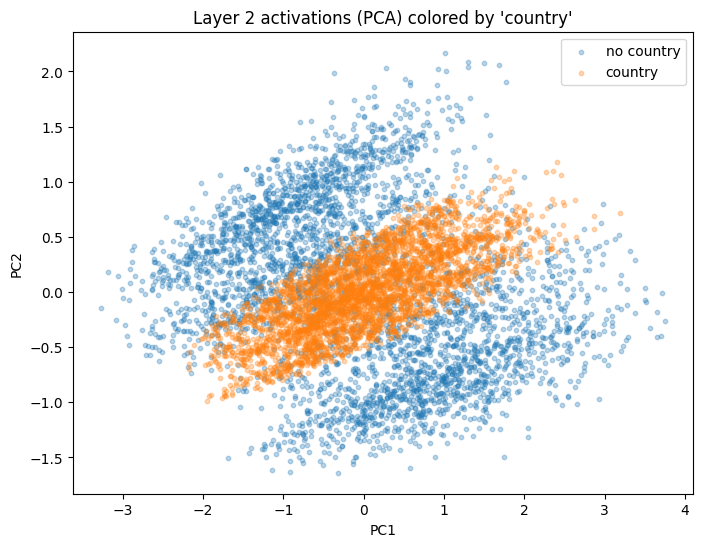

Explained variance: PC1=0.609, PC2=0.173


In [4]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# PCA on layer 2 activations
pca = PCA(n_components=2)
train_pca = pca.fit_transform(train_acts)

# Color by country label (feature index 5)
country_labels = train_labels[:, 5]

plt.figure(figsize=(8, 6))
plt.scatter(train_pca[country_labels == 0, 0], train_pca[country_labels == 0, 1],
            alpha=0.3, s=10, label="no country")
plt.scatter(train_pca[country_labels == 1, 0], train_pca[country_labels == 1, 1],
            alpha=0.3, s=10, label="country")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Layer 2 activations (PCA) colored by 'country'")
plt.legend()
plt.show()

print(f"Explained variance: PC1={pca.explained_variance_ratio_[0]:.3f}, PC2={pca.explained_variance_ratio_[1]:.3f}")

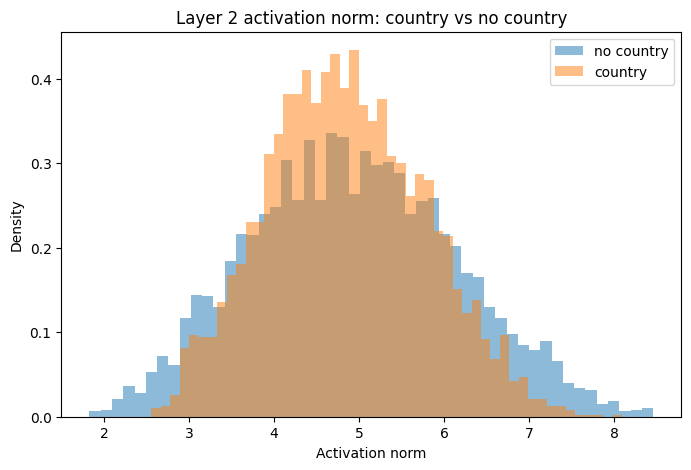

In [5]:
# Check if country is encoded in the norm of the activation vector
norms = np.linalg.norm(train_acts, axis=1)

plt.figure(figsize=(8, 5))
plt.hist(norms[country_labels == 0], bins=50, alpha=0.5, label="no country", density=True)
plt.hist(norms[country_labels == 1], bins=50, alpha=0.5, label="country", density=True)
plt.xlabel("Activation norm")
plt.ylabel("Density")
plt.title("Layer 2 activation norm: country vs no country")
plt.legend()
plt.show()

In [6]:
from sklearn.neural_network import MLPClassifier

# Train nonlinear probes of increasing complexity for country
print(f"{'Probe':<30} {'Train Acc':>10} {'Test Acc':>10}")
print("-" * 52)

configs = [
    ("Linear (logistic reg)", None),
    ("MLP (64,)", (64,)),
    ("MLP (64, 64)", (64, 64)),
    ("MLP (64, 64, 64)", (64, 64, 64)),
]

country_idx = 5
for name, hidden in configs:
    if hidden is None:
        clf = LogisticRegression(max_iter=1000)
    else:
        clf = MLPClassifier(hidden_layer_sizes=hidden, max_iter=1000, random_state=42)
    clf.fit(train_acts, train_labels[:, country_idx])
    train_acc = accuracy_score(train_labels[:, country_idx], clf.predict(train_acts))
    test_acc = accuracy_score(test_labels[:, country_idx], clf.predict(test_acts))
    print(f"{name:<30} {train_acc:>10.4f} {test_acc:>10.4f}")

Probe                           Train Acc   Test Acc
----------------------------------------------------
Linear (logistic reg)              0.4676     0.4280
MLP (64,)                          1.0000     0.9620
MLP (64, 64)                       1.0000     0.9647
MLP (64, 64, 64)                   1.0000     0.9627


2-neuron probe test acc: 0.7227


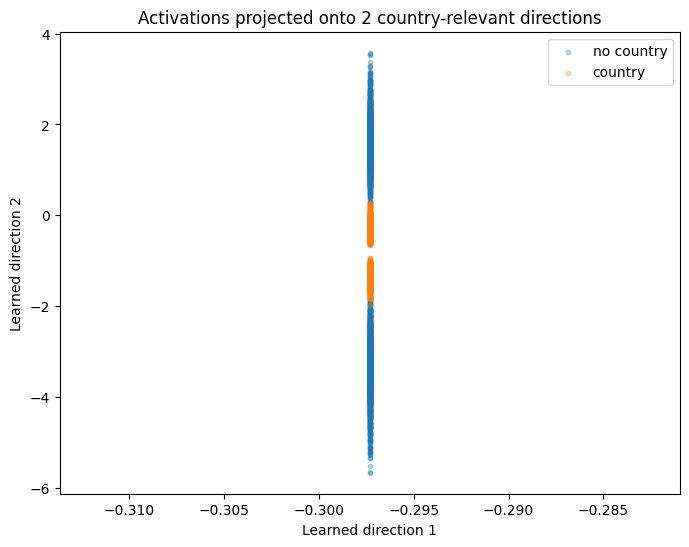

In [7]:
# Train a 2-neuron MLP probe to find the 2 most country-relevant directions
mlp2d = MLPClassifier(hidden_layer_sizes=(2,), max_iter=2000, random_state=42)
mlp2d.fit(train_acts, train_labels[:, country_idx])
print(f"2-neuron probe test acc: {accuracy_score(test_labels[:, country_idx], mlp2d.predict(test_acts)):.4f}")

# The first layer projects 64-dim activations to 2D: h = ReLU(W @ x + b)
# W is (64, 2), so each column is a direction in activation space
W = mlp2d.coefs_[0]  # (64, 2)
b = mlp2d.intercepts_[0]  # (2,)

# Project activations onto these 2 learned directions (before ReLU)
train_proj = train_acts @ W + b

plt.figure(figsize=(8, 6))
plt.scatter(train_proj[country_labels == 0, 0], train_proj[country_labels == 0, 1],
            alpha=0.3, s=10, label="no country")
plt.scatter(train_proj[country_labels == 1, 0], train_proj[country_labels == 1, 1],
            alpha=0.3, s=10, label="country")
plt.xlabel("Learned direction 1")
plt.ylabel("Learned direction 2")
plt.title("Activations projected onto 2 country-relevant directions")
plt.legend()
plt.show()

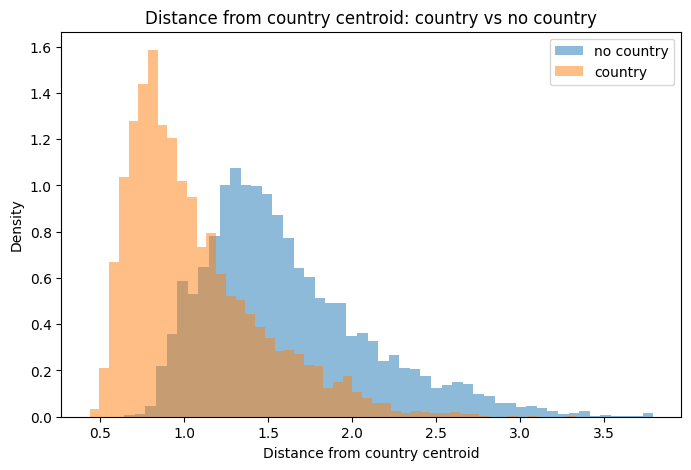

Best threshold accuracy (train): 0.7643 at distance < 1.162


In [8]:
# Check if country is encoded as distance from the country centroid
country_centroid = train_acts[country_labels == 1].mean(axis=0)
dists = np.linalg.norm(train_acts - country_centroid, axis=1)

plt.figure(figsize=(8, 5))
plt.hist(dists[country_labels == 0], bins=50, alpha=0.5, label="no country", density=True)
plt.hist(dists[country_labels == 1], bins=50, alpha=0.5, label="country", density=True)
plt.xlabel("Distance from country centroid")
plt.ylabel("Density")
plt.title("Distance from country centroid: country vs no country")
plt.legend()
plt.show()

# Also check accuracy of a simple threshold on this distance
from sklearn.metrics import accuracy_score
best_acc = 0
for threshold in np.linspace(dists.min(), dists.max(), 1000):
    preds = (dists < threshold).astype(int)
    acc = accuracy_score(train_labels[:, country_idx], preds)
    if acc > best_acc:
        best_acc = acc
        best_threshold = threshold
print(f"Best threshold accuracy (train): {best_acc:.4f} at distance < {best_threshold:.3f}")

In [9]:
# Logistic regression on squared distances per dimension from country centroid
# This lets the model learn WHICH dimensions matter for the radial structure
train_sq_dists = (train_acts - country_centroid) ** 2  # (N, 64)
test_sq_dists = (test_acts - country_centroid) ** 2

clf_radial = LogisticRegression(max_iter=1000)
clf_radial.fit(train_sq_dists, train_labels[:, country_idx])
train_acc = accuracy_score(train_labels[:, country_idx], clf_radial.predict(train_sq_dists))
test_acc = accuracy_score(test_labels[:, country_idx], clf_radial.predict(test_sq_dists))
print(f"Radial probe (squared dists per dim) — Train: {train_acc:.4f}, Test: {test_acc:.4f}")

# Which dimensions matter most? Look at the learned weights
weights = clf_radial.coef_[0]
top_dims = np.argsort(np.abs(weights))[::-1][:10]
print(f"\nTop 10 dimensions by weight magnitude:")
for d in top_dims:
    print(f"  dim {d:2d}: weight = {weights[d]:+.4f}")

Radial probe (squared dists per dim) — Train: 0.8891, Test: 0.8593

Top 10 dimensions by weight magnitude:
  dim  1: weight = -8.4615
  dim 23: weight = -8.3089
  dim 10: weight = -8.0486
  dim 44: weight = -6.8253
  dim 19: weight = -4.9764
  dim 46: weight = -3.5139
  dim 43: weight = +2.9741
  dim 34: weight = +2.8694
  dim 51: weight = +2.6926
  dim 36: weight = -2.4237


In [10]:
# Learn the optimal center point and per-dimension weights for a radial probe
# Model: sigmoid(sum_i w_i * (x_i - c_i)^2 + b) -> country probability
# This jointly optimizes the center c and the weights w

import torch.optim as optim

class RadialProbe(nn.Module):
    def __init__(self, dim=64):
        super().__init__()
        self.center = nn.Parameter(torch.from_numpy(country_centroid).float())  # init at centroid
        self.weights = nn.Parameter(torch.zeros(dim))
        self.bias = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        sq_dists = (x - self.center) ** 2  # (N, 64)
        logits = (sq_dists * self.weights).sum(dim=1) + self.bias  # (N,)
        return logits

probe = RadialProbe()
optimizer = optim.Adam(probe.parameters(), lr=0.01)
loss_fn = nn.BCEWithLogitsLoss()

train_x = torch.from_numpy(train_acts).float()
train_y = torch.from_numpy(train_labels[:, country_idx]).float()
test_x = torch.from_numpy(test_acts).float()
test_y = torch.from_numpy(test_labels[:, country_idx]).float()

for epoch in range(2000):
    logits = probe(train_x)
    loss = loss_fn(logits, train_y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

with torch.no_grad():
    train_preds = (torch.sigmoid(probe(train_x)) > 0.5).int().numpy()
    test_preds = (torch.sigmoid(probe(test_x)) > 0.5).int().numpy()
    train_acc = accuracy_score(train_labels[:, country_idx], train_preds)
    test_acc = accuracy_score(test_labels[:, country_idx], test_preds)

print(f"Learned-center radial probe — Train: {train_acc:.4f}, Test: {test_acc:.4f}")

# How far did the center move from the naive centroid?
shift = torch.norm(probe.center - torch.from_numpy(country_centroid).float()).item()
print(f"Center shifted {shift:.4f} from naive centroid")

# Top dimensions by learned weight magnitude
w = probe.weights.detach().numpy()
top = np.argsort(np.abs(w))[::-1][:10]
print(f"\nTop 10 dimensions by learned weight:")
for d in top:
    print(f"  dim {d:2d}: weight = {w[d]:+.4f}")

Learned-center radial probe — Train: 0.9053, Test: 0.8693
Center shifted 0.0000 from naive centroid

Top 10 dimensions by learned weight:
  dim 23: weight = -16.6437
  dim  1: weight = -12.9731
  dim 44: weight = -12.7658
  dim 10: weight = -7.4914
  dim 43: weight = +6.2467
  dim 19: weight = -6.0761
  dim 46: weight = -4.1673
  dim 55: weight = +2.8366
  dim 34: weight = +2.7559
  dim 36: weight = -2.3556


In [11]:
# Band/slab probe: country = point is between two parallel hyperplanes
# For each dimension, check if lo_i < x_i < hi_i
# We use sigmoid soft-bounds: sigmoid(x - lo) * sigmoid(hi - x) ≈ 1 when x is in [lo, hi]

class BandProbe(nn.Module):
    def __init__(self, dim=64):
        super().__init__()
        # Initialize lo/hi from country data percentiles
        country_acts = torch.from_numpy(train_acts[country_labels == 1]).float()
        self.lo = nn.Parameter(country_acts.quantile(0.1, dim=0))
        self.hi = nn.Parameter(country_acts.quantile(0.9, dim=0))
        self.weights = nn.Parameter(torch.zeros(dim))
        self.sharpness = nn.Parameter(torch.tensor(1.0))
        self.bias = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        # How much each dimension is "in bounds" (soft)
        in_lo = torch.sigmoid(self.sharpness * (x - self.lo))  # (N, 64)
        in_hi = torch.sigmoid(self.sharpness * (self.hi - x))  # (N, 64)
        in_band = in_lo * in_hi  # (N, 64) — near 1 if in [lo, hi], near 0 otherwise
        logits = (in_band * self.weights).sum(dim=1) + self.bias
        return logits

band = BandProbe()
optimizer = optim.Adam(band.parameters(), lr=0.01)

for epoch in range(3000):
    logits = band(train_x)
    loss = loss_fn(logits, train_y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

with torch.no_grad():
    train_preds = (torch.sigmoid(band(train_x)) > 0.5).int().numpy()
    test_preds = (torch.sigmoid(band(test_x)) > 0.5).int().numpy()
    train_acc = accuracy_score(train_labels[:, country_idx], train_preds)
    test_acc = accuracy_score(test_labels[:, country_idx], test_preds)

print(f"Band probe — Train: {train_acc:.4f}, Test: {test_acc:.4f}")

# Top dimensions by weight
bw = band.weights.detach().numpy()
top = np.argsort(np.abs(bw))[::-1][:10]
print(f"\nTop 10 dimensions by weight:")
for d in top:
    lo_val = band.lo[d].item()
    hi_val = band.hi[d].item()
    print(f"  dim {d:2d}: weight = {bw[d]:+.4f}, band = [{lo_val:.3f}, {hi_val:.3f}]")

Band probe — Train: 0.8881, Test: 0.8613

Top 10 dimensions by weight:
  dim  1: weight = +10.0646, band = [0.340, 1.748]
  dim 44: weight = +9.4298, band = [-0.069, 0.712]
  dim 23: weight = +8.5881, band = [0.083, 0.724]
  dim 10: weight = +8.5075, band = [0.681, 2.114]
  dim 43: weight = +8.2899, band = [-1.030, 0.736]
  dim 46: weight = +6.1736, band = [0.946, 2.938]
  dim 19: weight = +6.0513, band = [0.465, 1.941]
  dim 36: weight = +5.5057, band = [1.123, 3.707]
  dim 55: weight = -3.4710, band = [-0.604, 2.001]
  dim 51: weight = +2.4185, band = [0.464, 3.147]


In [12]:
# Inspect the actual model weights for decoding country from layer 2
# After layer 2 (post-ReLU), the model does:
#   h3 = ReLU(W3 @ layer2_acts + b3)   — layer 3
#   logits = W4 @ h3 + b4              — layer 4 (final)
# Country is logit index 5

W3 = m.layers[6].weight.detach().numpy()  # (64, 64)
b3 = m.layers[6].bias.detach().numpy()    # (64,)
# layers[7] is ReLU
W4 = m.layers[8].weight.detach().numpy()  # (8, 64)
b4 = m.layers[8].bias.detach().numpy()    # (8,)

# Which hidden-3 neurons matter for country (logit 5)?
country_weights = W4[5]  # (64,) — weight from each h3 neuron to country logit
top_neurons = np.argsort(np.abs(country_weights))[::-1][:10]

print("Layer 4 weights for country logit (top 10 h3 neurons):")
for n in top_neurons:
    print(f"  neuron {n:2d}: weight = {country_weights[n]:+.4f}")

print(f"\nCountry bias (b4[5]): {b4[5]:.4f}")
print(f"\nTotal h3 neurons with |weight| > 0.1: {(np.abs(country_weights) > 0.1).sum()}")
print(f"Total h3 neurons with |weight| > 0.5: {(np.abs(country_weights) > 0.5).sum()}")

Layer 4 weights for country logit (top 10 h3 neurons):
  neuron  9: weight = -4.2376
  neuron  6: weight = -3.8677
  neuron 47: weight = -3.8130
  neuron  5: weight = -3.7886
  neuron  0: weight = -3.7135
  neuron 33: weight = -3.7126
  neuron 56: weight = -3.3323
  neuron 60: weight = -3.1873
  neuron 36: weight = -3.1277
  neuron 54: weight = -2.9752

Country bias (b4[5]): 0.7165

Total h3 neurons with |weight| > 0.1: 46
Total h3 neurons with |weight| > 0.5: 34


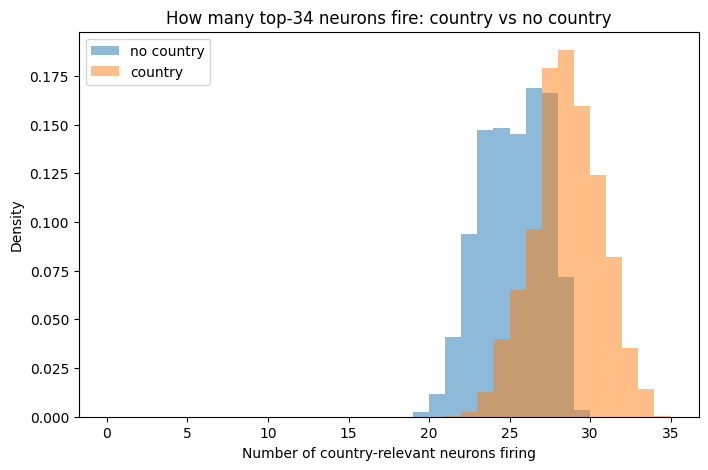

In [13]:
# Verify: do fewer layer-3 neurons fire for country points?
with torch.no_grad():
    h3 = m.layers[:8](train_emb).numpy()  # layers 0-7: through ReLU after layer 3

# Count how many of the top 34 country-relevant neurons fire (> 0) per sample
relevant_neurons = np.argsort(np.abs(country_weights))[::-1][:34]
n_firing = (h3[:, relevant_neurons] > 0).sum(axis=1)

plt.figure(figsize=(8, 5))
plt.hist(n_firing[country_labels == 0], bins=range(0, 36), alpha=0.5, label="no country", density=True)
plt.hist(n_firing[country_labels == 1], bins=range(0, 36), alpha=0.5, label="country", density=True)
plt.xlabel("Number of country-relevant neurons firing")
plt.ylabel("Density")
plt.title("How many top-34 neurons fire: country vs no country")
plt.legend()
plt.show()

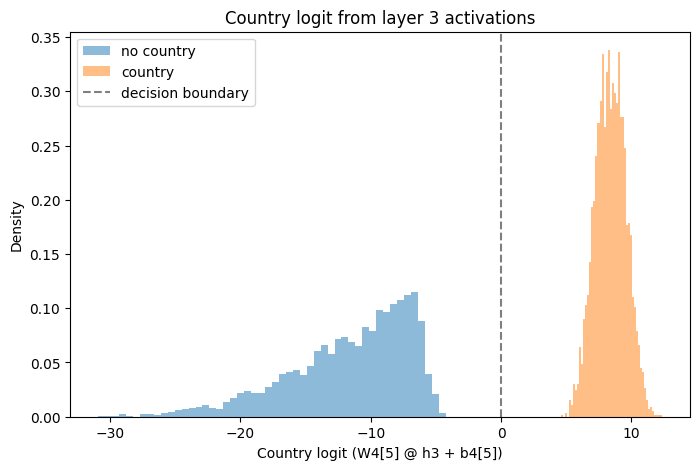

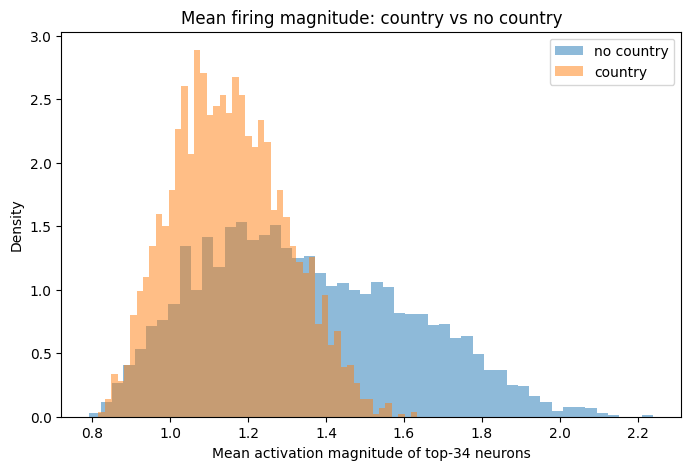

In [14]:
# Check the actual weighted contribution of layer-3 neurons to the country logit
# country_logit = sum(W4[5] * h3) + b4[5]
with torch.no_grad():
    h3_train = m.layers[:8](train_emb).numpy()  # (N, 64) post-ReLU

# Total country logit contribution from h3
country_logit_contribution = h3_train @ country_weights + b4[5]  # (N,)

plt.figure(figsize=(8, 5))
plt.hist(country_logit_contribution[country_labels == 0], bins=50, alpha=0.5, label="no country", density=True)
plt.hist(country_logit_contribution[country_labels == 1], bins=50, alpha=0.5, label="country", density=True)
plt.axvline(x=0, color='black', linestyle='--', alpha=0.5, label="decision boundary")
plt.xlabel("Country logit (W4[5] @ h3 + b4[5])")
plt.ylabel("Density")
plt.title("Country logit from layer 3 activations")
plt.legend()
plt.show()

# Also look at mean activation magnitude (not just count) for country-relevant neurons
mean_magnitude = h3_train[:, relevant_neurons].mean(axis=1)

plt.figure(figsize=(8, 5))
plt.hist(mean_magnitude[country_labels == 0], bins=50, alpha=0.5, label="no country", density=True)
plt.hist(mean_magnitude[country_labels == 1], bins=50, alpha=0.5, label="country", density=True)
plt.xlabel("Mean activation magnitude of top-34 neurons")
plt.ylabel("Density")
plt.title("Mean firing magnitude: country vs no country")
plt.legend()
plt.show()

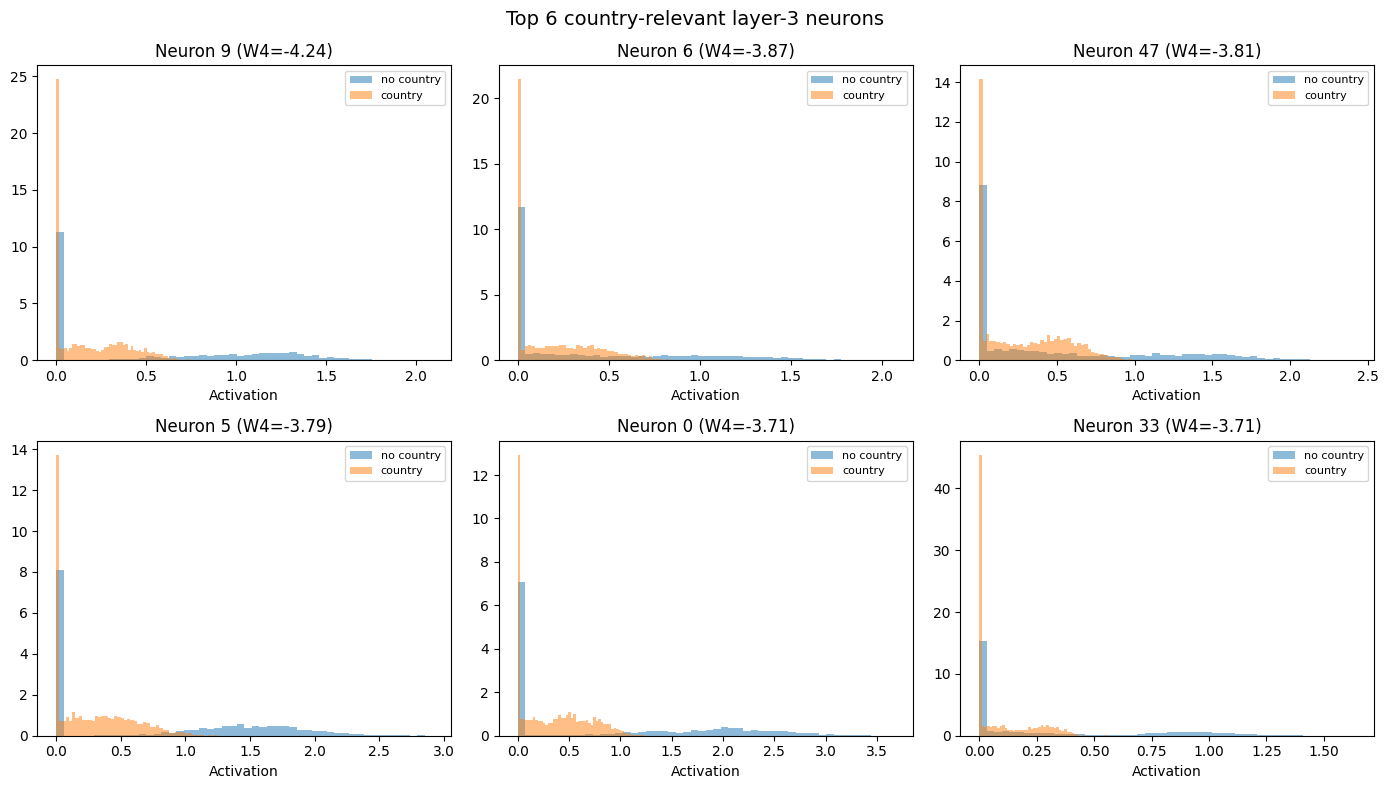

In [15]:
# Look at individual layer-3 neuron activations for the top country-relevant neurons
# Each neuron computes ReLU(w_i @ layer2_act + b_i)
# If country is a polytope, each neuron should fire small for country, large for non-country

top6 = np.argsort(np.abs(country_weights))[::-1][:6]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for idx, neuron in enumerate(top6):
    ax = axes[idx // 3, idx % 3]
    vals = h3_train[:, neuron]
    ax.hist(vals[country_labels == 0], bins=50, alpha=0.5, label="no country", density=True)
    ax.hist(vals[country_labels == 1], bins=50, alpha=0.5, label="country", density=True)
    ax.set_title(f"Neuron {neuron} (W4={country_weights[neuron]:+.2f})")
    ax.set_xlabel("Activation")
    ax.legend(fontsize=8)
plt.suptitle("Top 6 country-relevant layer-3 neurons", fontsize=14)
plt.tight_layout()
plt.show()

## Task 2: Explain how that feature is represented

Describe the geometric structure the model uses to represent this feature. Show the analysis you used to convince yourself.

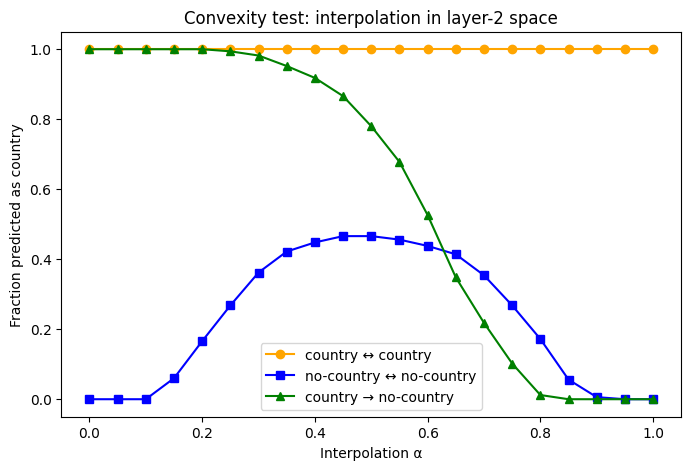

In [16]:
# Convexity test: interpolate between pairs of points and check country prediction
# If country is a convex polytope, interpolating between two country points
# should stay country the whole way.

np.random.seed(42)
n_pairs = 500
alphas = np.linspace(0, 1, 21)  # 21 steps from point A to point B

country_acts = train_acts[country_labels == 1]
no_country_acts = train_acts[country_labels == 0]

def test_interpolation(acts, label):
    n = len(acts)
    idx_a = np.random.randint(0, n, size=n_pairs)
    idx_b = np.random.randint(0, n, size=n_pairs)
    
    country_frac = []
    for alpha in alphas:
        interp = (1 - alpha) * acts[idx_a] + alpha * acts[idx_b]  # (n_pairs, 64)
        interp_t = torch.from_numpy(interp).float()
        with torch.no_grad():
            # Run through layers 3+4 (layer 6 onward) to get logits
            logits = m.layers[6:](interp_t)  # (n_pairs, 8)
            preds = (torch.sigmoid(logits[:, country_idx]) > 0.5).float().mean().item()
        country_frac.append(preds)
    return country_frac

country_country = test_interpolation(country_acts, "country-country")
nocountry_nocountry = test_interpolation(no_country_acts, "nocountry-nocountry")

# Also test country <-> no-country interpolations
idx_c = np.random.randint(0, len(country_acts), size=n_pairs)
idx_nc = np.random.randint(0, len(no_country_acts), size=n_pairs)
mixed_frac = []
for alpha in alphas:
    interp = (1 - alpha) * country_acts[idx_c] + alpha * no_country_acts[idx_nc]
    interp_t = torch.from_numpy(interp).float()
    with torch.no_grad():
        logits = m.layers[6:](interp_t)
        preds = (torch.sigmoid(logits[:, country_idx]) > 0.5).float().mean().item()
    mixed_frac.append(preds)

plt.figure(figsize=(8, 5))
plt.plot(alphas, country_country, 'o-', label="country ↔ country", color="orange")
plt.plot(alphas, nocountry_nocountry, 's-', label="no-country ↔ no-country", color="blue")
plt.plot(alphas, mixed_frac, '^-', label="country → no-country", color="green")
plt.xlabel("Interpolation α")
plt.ylabel("Fraction predicted as country")
plt.title("Convexity test: interpolation in layer-2 space")
plt.legend()
plt.ylim(-0.05, 1.05)
plt.show()

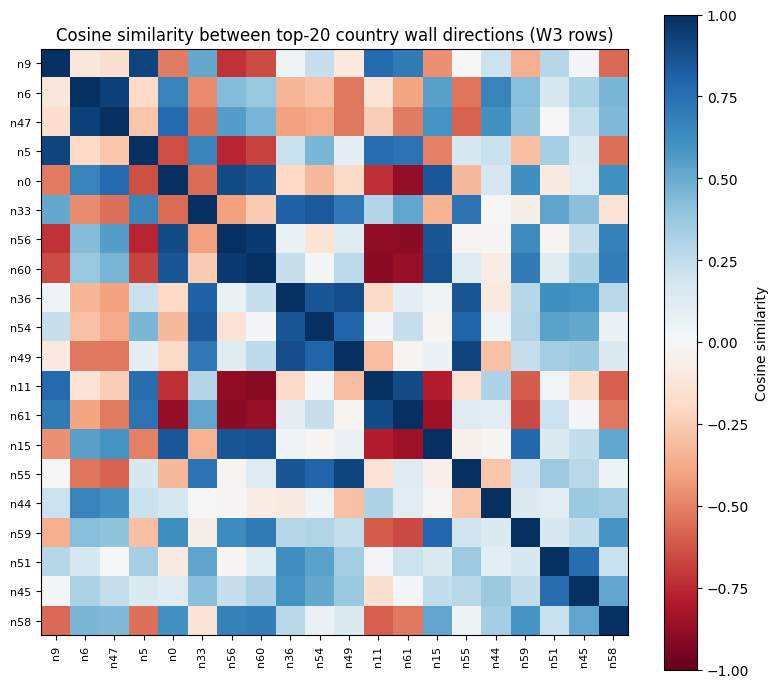

Mean pairwise cosine similarity: 0.1191
Std: 0.4772
Min: -0.9033, Max: 0.9559


In [17]:
# Cosine similarity between the wall directions (rows of W3) for top country neurons
from sklearn.metrics.pairwise import cosine_similarity

top20 = np.argsort(np.abs(country_weights))[::-1][:20]
wall_directions = W3[top20]  # (20, 64) — each row is a wall normal vector

cos_sim = cosine_similarity(wall_directions)

plt.figure(figsize=(8, 7))
plt.imshow(cos_sim, cmap='RdBu', vmin=-1, vmax=1)
plt.colorbar(label="Cosine similarity")
plt.xticks(range(20), [f"n{top20[i]}" for i in range(20)], rotation=90, fontsize=8)
plt.yticks(range(20), [f"n{top20[i]}" for i in range(20)], fontsize=8)
plt.title("Cosine similarity between top-20 country wall directions (W3 rows)")
plt.tight_layout()
plt.show()

# Summary stats
upper_tri = cos_sim[np.triu_indices(20, k=1)]
print(f"Mean pairwise cosine similarity: {upper_tri.mean():.4f}")
print(f"Std: {upper_tri.std():.4f}")
print(f"Min: {upper_tri.min():.4f}, Max: {upper_tri.max():.4f}")

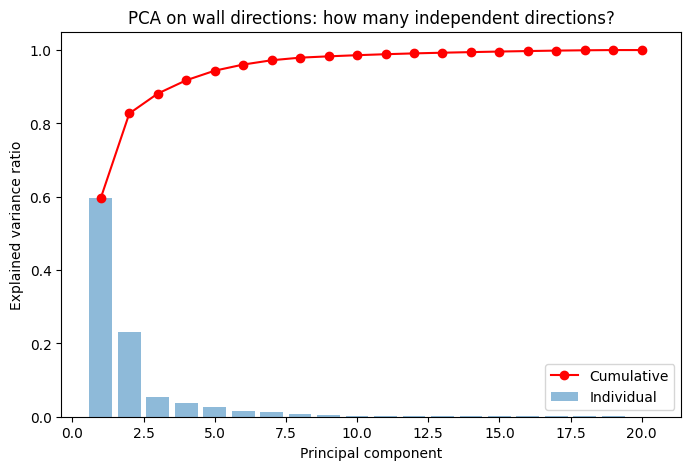

  PC 1: cumulative variance = 0.5969
  PC 2: cumulative variance = 0.8271
  PC 3: cumulative variance = 0.8814
  PC 4: cumulative variance = 0.9177
  PC 5: cumulative variance = 0.9438
  PC 6: cumulative variance = 0.9604
  PC 7: cumulative variance = 0.9722
  PC 8: cumulative variance = 0.9793
  PC 9: cumulative variance = 0.9829
  PC 10: cumulative variance = 0.9860


In [18]:
# PCA on the wall directions to find how many independent directions they span
pca_walls = PCA()
pca_walls.fit(wall_directions)

cumvar = np.cumsum(pca_walls.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.bar(range(1, len(cumvar) + 1), pca_walls.explained_variance_ratio_, alpha=0.5, label="Individual")
plt.plot(range(1, len(cumvar) + 1), cumvar, 'o-', color='red', label="Cumulative")
plt.xlabel("Principal component")
plt.ylabel("Explained variance ratio")
plt.title("PCA on wall directions: how many independent directions?")
plt.legend()
plt.show()

for i, cv in enumerate(cumvar[:10]):
    print(f"  PC {i+1}: cumulative variance = {cv:.4f}")

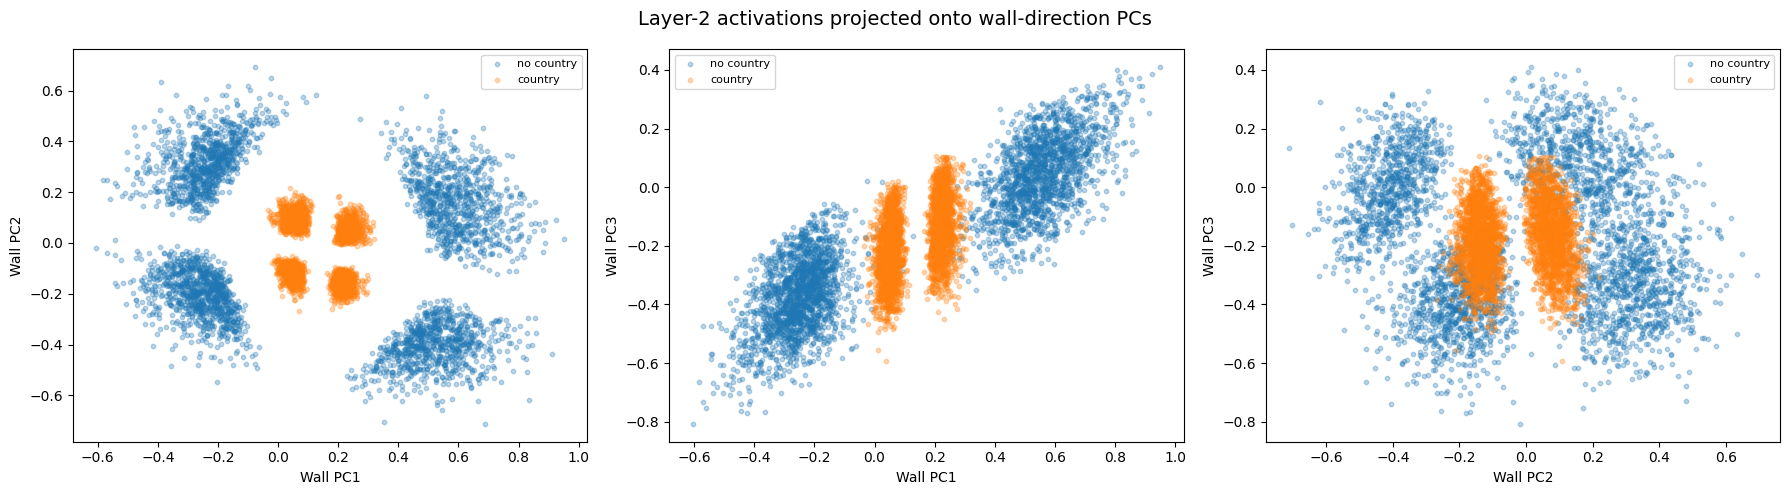

In [19]:
# Project layer-2 activations onto the top wall-direction PCs
wall_pcs = pca_walls.components_  # (20, 64) — each row is a PC direction

# Project all training data onto top 3 wall PCs
train_wall_proj = train_acts @ wall_pcs[:3].T  # (N, 3)

# 2D: PC1 vs PC2
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

pairs = [(0, 1), (0, 2), (1, 2)]
for ax, (i, j) in zip(axes, pairs):
    ax.scatter(train_wall_proj[country_labels == 0, i], train_wall_proj[country_labels == 0, j],
               alpha=0.3, s=10, label="no country")
    ax.scatter(train_wall_proj[country_labels == 1, i], train_wall_proj[country_labels == 1, j],
               alpha=0.3, s=10, label="country")
    ax.set_xlabel(f"Wall PC{i+1}")
    ax.set_ylabel(f"Wall PC{j+1}")
    ax.legend(fontsize=8)

plt.suptitle("Layer-2 activations projected onto wall-direction PCs", fontsize=14)
plt.tight_layout()
plt.show()

In [20]:
!pip install plotly

In [21]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter3d(
    x=train_wall_proj[country_labels == 0, 0],
    y=train_wall_proj[country_labels == 0, 1],
    z=train_wall_proj[country_labels == 0, 2],
    mode='markers',
    marker=dict(size=2, color='blue', opacity=0.2),
    name='no country'
))

fig.add_trace(go.Scatter3d(
    x=train_wall_proj[country_labels == 1, 0],
    y=train_wall_proj[country_labels == 1, 1],
    z=train_wall_proj[country_labels == 1, 2],
    mode='markers',
    marker=dict(size=2, color='orange', opacity=0.5),
    name='country'
))

fig.update_layout(
    title="Layer-2 activations projected onto wall-direction PCs (3D)",
    scene=dict(xaxis_title="Wall PC1", yaxis_title="Wall PC2", zaxis_title="Wall PC3"),
    width=800, height=600
)

fig.show()

This is strong evidence for the convex polytope.

  - Orange (country↔country): stays at 1.0 the entire way — every midpoint between two country points is still country. This is exactly what convexity predicts.
  - Green (country→no-country): smoothly drops from 1.0 to 0.0, as expected when you walk from inside the polytope to outside.
  - Blue (no-country↔no-country): bumps up to ~0.46 in the middle — interpolating between two outside points sometimes passes through the polytope. This is also consistent with a
  convex region sitting in the middle of the space.

  The orange line being perfectly flat at 1.0 is the key result. If the region were non-convex (e.g., a donut or two separate clusters), some midpoints between country pairs would fall
  outside and the orange line would dip. It doesn't.

  So the conclusion holds: country is encoded as the interior of a convex polytope in the 64-dimensional layer-2 activation space, with ~34 facets. The model decodes it by using layer-3
   ReLU neurons as boundary detectors — each one fires when you're outside its facet, suppressing the country logit.

## Task 3: Train a model with an even weirder representation

*Open ended.* Train your own model that encodes that feature (or some other feature) in a more interesting way than ours. "More interesting" is up to you to define and defend.

## What you'll submit

A single google doc, documenting what you tried, what worked, what didn't, and what structure emerged in the trained model. We'll happily read about your failures if the path to them was thoughtful.